In [1]:
!pip install matplotlib-venn

In [2]:
import pandas as pd
global_stability_LC_rf = pd.read_pickle('feature_freq_LC_rf_threshold.pkl')
global_stability_Lisbon_rf = pd.read_pickle('feature_rf_Lisbon_threshold.pkl')
global_stability_Coimbra_rf = pd.read_pickle('feature_rf_Cooimbra_threshold.pkl')
global_stability_Lisbon_plsda = pd.read_pickle('global_stable_counts_Lisbon_threshold.pkl')
global_stability_Coimbra_plsda = pd.read_pickle('global_stability_Coimbra_threshold.pkl')
global_stability_LC_plsda = pd.read_pickle('global_stability_LC_threshold.pkl')
global_stability_Coimbra_plsda_no = pd.read_pickle('global_stability_Coimbra.pkl')
global_stability_Lisbon_plsda_no = pd.read_pickle('global_stable_counts_Lisbon.pkl')
global_stability_LC_plsda_no = pd.read_pickle('global_stability_LC.pkl')
global_stability_LC_rf_no = pd.read_pickle('feature_freq_LC_rf.pkl')
global_stability_Lisbon_rf_no = pd.read_pickle('feature_rf_Lisbon.pkl')
global_stability_Coimbra_rf_no = pd.read_pickle('feature_rf_Coimbra.pkl')

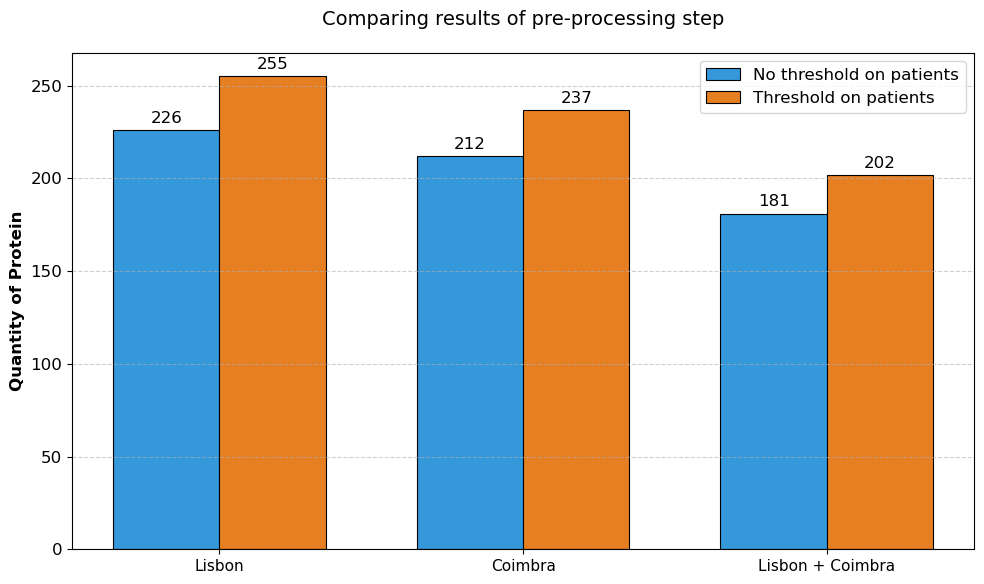

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. INSERISCI I TUOI DATI QUI ---
# Nomi delle coppie (es. Campione 1, Campione 2, ecc.)
categorie = ['Lisbon', 'Coimbra', 'Lisbon + Coimbra']

# Valori proteici per il primo set di 3 (Dataset A)
proteine_A = [226, 212, 181] 

# Valori proteici per il secondo set di 3 (Dataset B)
proteine_B = [255, 237, 202] 
# ------------------------------------

# Configurazione posizioni delle barre
x = np.arange(len(categorie))  # Posizioni delle etichette (0, 1, 2)
width = 0.35  # Larghezza delle singole barre

fig, ax = plt.subplots(figsize=(10, 6))

# Creazione delle barre raggruppate
# Spostiamo le barre A a sinistra di metà larghezza e le B a destra
rects1 = ax.bar(x - width/2, proteine_A, width, label='No threshold on patients', color='#3498db', edgecolor='black', linewidth=0.8)
rects2 = ax.bar(x + width/2, proteine_B, width, label='Threshold on patients', color='#e67e22', edgecolor='black', linewidth=0.8)

# --- 2. PERSONALIZZAZIONE ESTETICA ---
ax.set_ylabel('Quantity of Protein', fontsize=12, fontweight='bold')
ax.set_title('Comparing results of pre-processing step', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(categorie, fontsize=11)
ax.legend()

# Aggiungiamo una griglia leggera solo sull'asse Y per facilitare la lettura
ax.yaxis.grid(True, linestyle='--', alpha=0.6)

# Funzione per scrivere il valore sopra ogni barra (molto utile!)
ax.bar_label(rects1, padding=3, fmt='%.0f')
ax.bar_label(rects2, padding=3, fmt='%.0f')

# Layout ottimizzato per non tagliare le scritte
fig.tight_layout()
fig.savefig('total_protein_comparing_threshold')
# Mostra il grafico
plt.show()

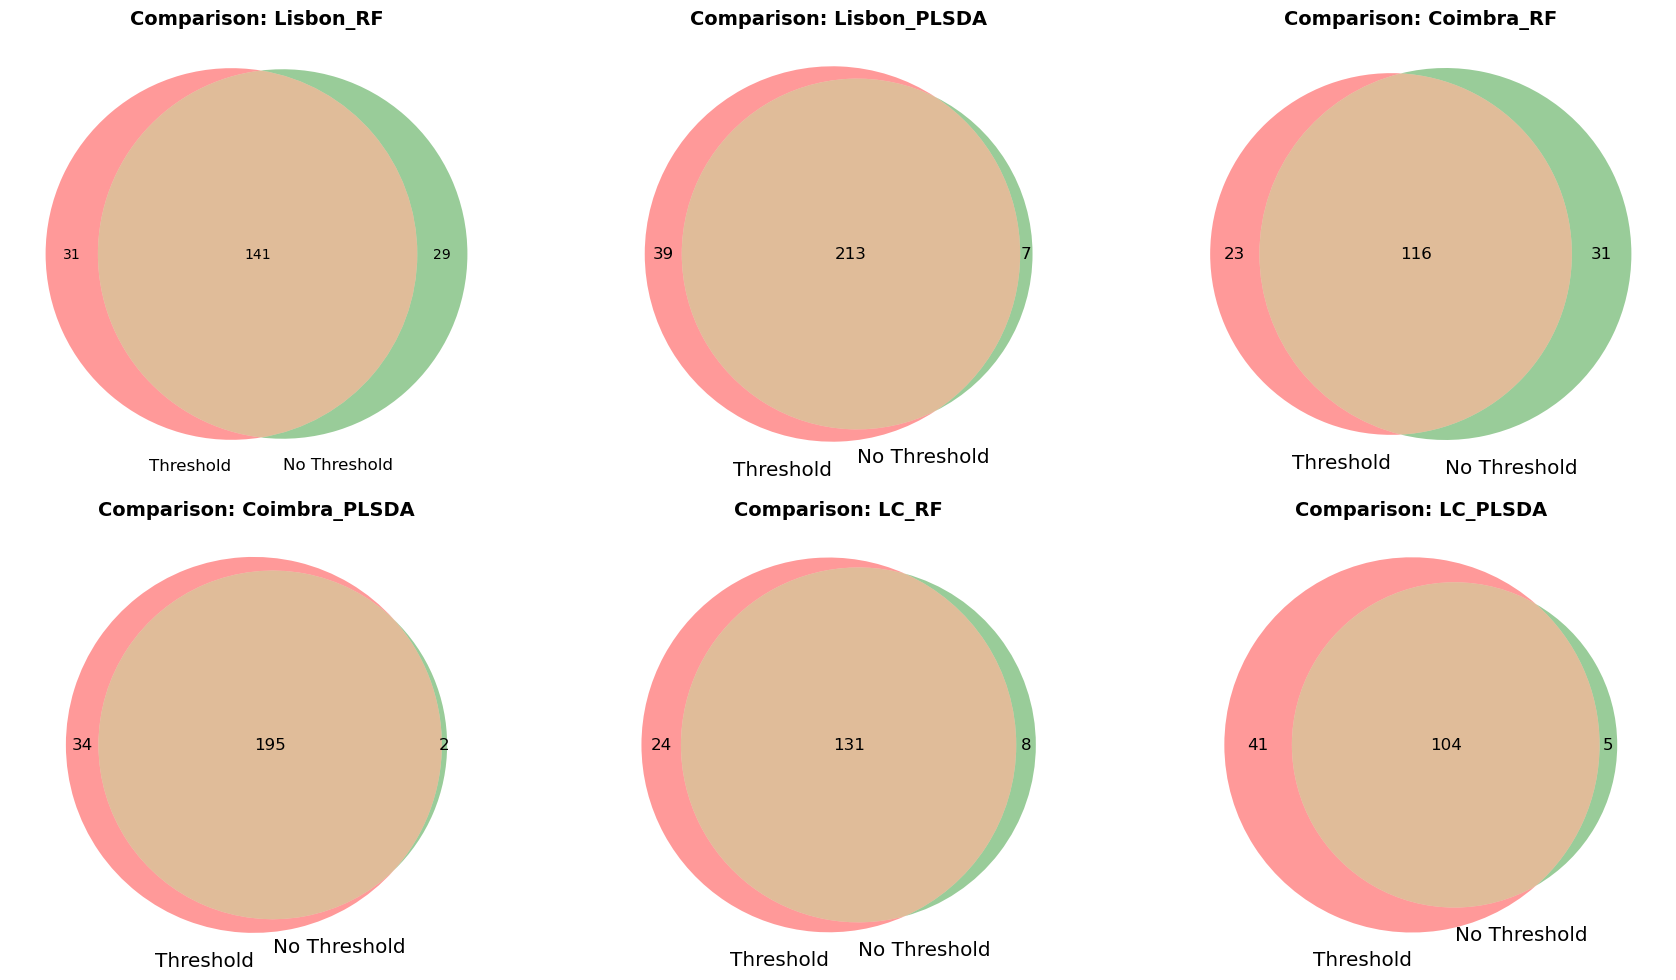

In [4]:

import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Prepariamo la figura (2 righe, 3 colonne)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Lista dei confronti (usiamo la stessa logica di prima)
comparison_list = [
    ('Lisbon_RF', global_stability_Lisbon_rf, global_stability_Lisbon_rf_no),
    ('Lisbon_PLSDA', global_stability_Lisbon_plsda, global_stability_Lisbon_plsda_no),
    ('Coimbra_RF', global_stability_Coimbra_rf, global_stability_Coimbra_rf_no),
    ('Coimbra_PLSDA', global_stability_Coimbra_plsda, global_stability_Coimbra_plsda_no),
    ('LC_RF', global_stability_LC_rf, global_stability_LC_rf_no),
    ('LC_PLSDA', global_stability_LC_plsda, global_stability_LC_plsda_no)
]

for i, (label, s_threshold, s_no_threshold) in enumerate(comparison_list):
    # Filtro proteine con frequenza > 0
    set_threshold = set(s_threshold[s_threshold > 0].index)
    set_no_threshold = set(s_no_threshold[s_no_threshold > 0].index)
    
    # Creazione del diagramma di Venn sul relativo subplot
    v = venn2([set_threshold, set_no_threshold], 
          set_labels=('Threshold', 'No Threshold'),
          ax=axes[i])
    
    # Personalizzazione estetica
    plt.rc('font', size=12)
    axes[i].set_title(f"Comparison: {label}", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("venn_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

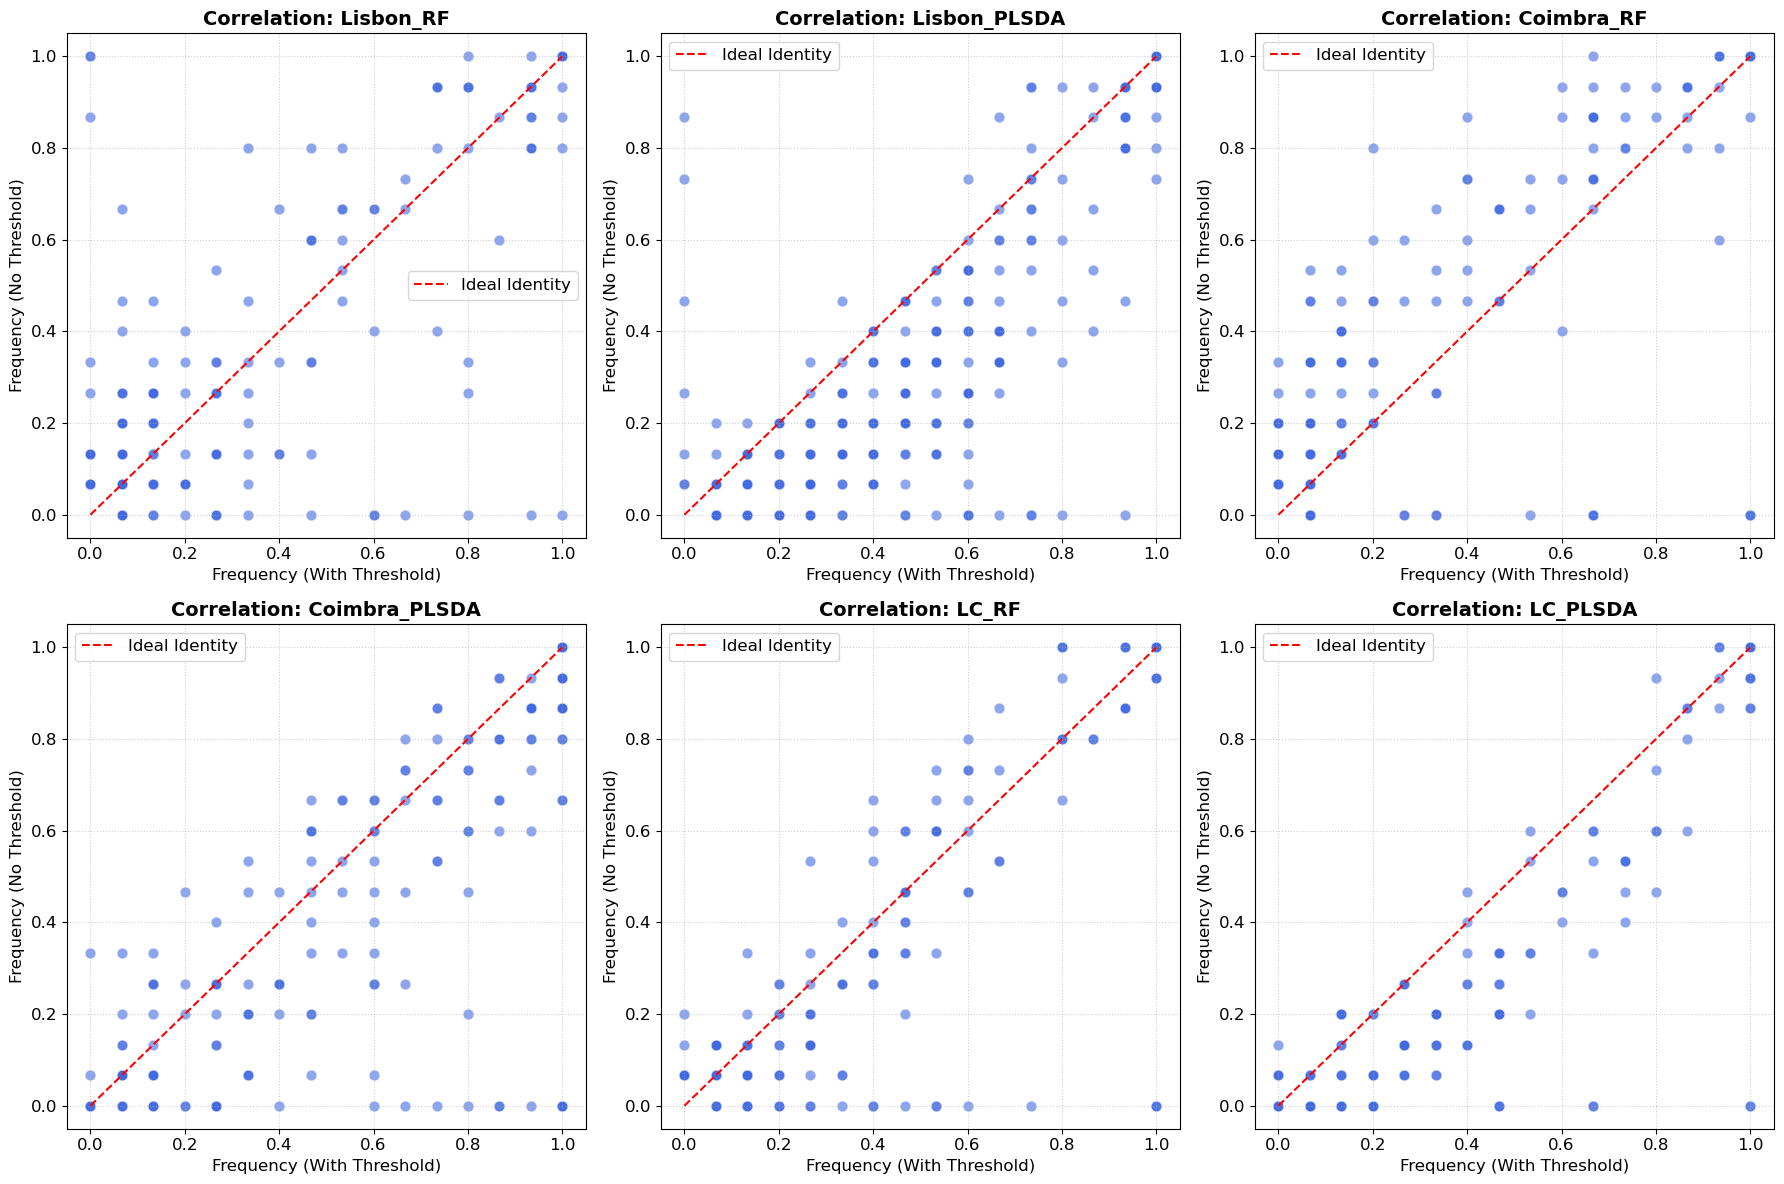

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Creiamo la griglia (2 righe, 3 colonne)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Lista dei confronti
comparison_list = [
    ('Lisbon_RF', global_stability_Lisbon_rf, global_stability_Lisbon_rf_no),
    ('Lisbon_PLSDA', global_stability_Lisbon_plsda, global_stability_Lisbon_plsda_no),
    ('Coimbra_RF', global_stability_Coimbra_rf, global_stability_Coimbra_rf_no),
    ('Coimbra_PLSDA', global_stability_Coimbra_plsda, global_stability_Coimbra_plsda_no),
    ('LC_RF', global_stability_LC_rf, global_stability_LC_rf_no),
    ('LC_PLSDA', global_stability_LC_plsda, global_stability_LC_plsda_no)
]

for i, (label, s_threshold, s_no_threshold) in enumerate(comparison_list):
    # Uniamo le due serie in un unico DataFrame per il plot
    # Usiamo l'unione degli indici per non perdere nessuna proteina
    df_temp = pd.concat([s_threshold, s_no_threshold], axis=1).fillna(0)
    df_temp.columns = ['With_Threshold', 'No_Threshold']
    
    # Scatter plot
    sns.scatterplot(data=df_temp, x='With_Threshold', y='No_Threshold', 
                    alpha=0.6, ax=axes[i], s=60, color='royalblue', edgecolor='w')
    
    # Disegniamo la diagonale perfetta (x = y)
    axes[i].plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=1.5, label='Ideal Identity')
    
    # Titoli e label
    axes[i].set_title(f"Correlation: {label}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Frequency (With Threshold)")
    axes[i].set_ylabel("Frequency (No Threshold)")
    axes[i].grid(True, linestyle=':', alpha=0.6)
    axes[i].legend()

plt.tight_layout()
plt.savefig("scatter_threshold_vs_no.png", dpi=300, bbox_inches='tight')
plt.show()

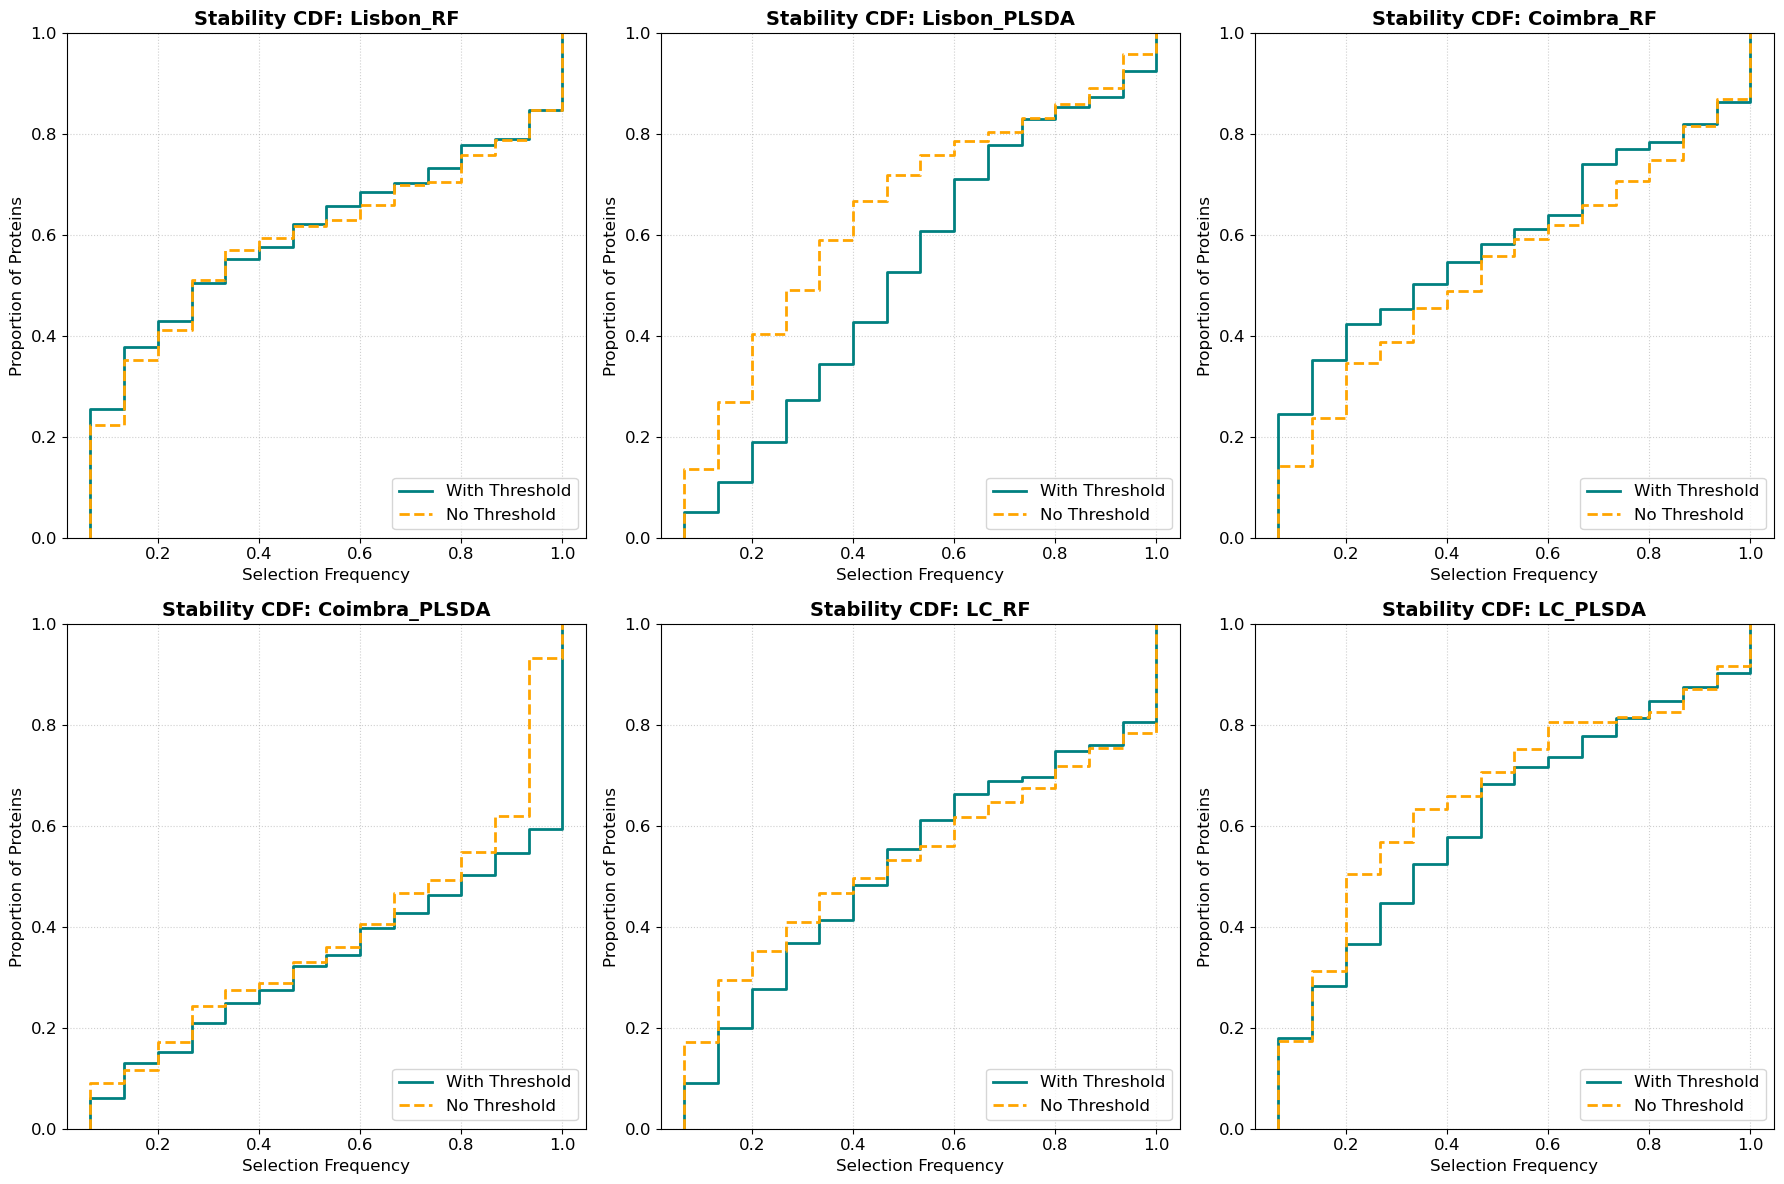

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Creiamo la griglia (2 righe, 3 colonne)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Lista dei confronti
comparison_list = [
    ('Lisbon_RF', global_stability_Lisbon_rf, global_stability_Lisbon_rf_no),
    ('Lisbon_PLSDA', global_stability_Lisbon_plsda, global_stability_Lisbon_plsda_no),
    ('Coimbra_RF', global_stability_Coimbra_rf, global_stability_Coimbra_rf_no),
    ('Coimbra_PLSDA', global_stability_Coimbra_plsda, global_stability_Coimbra_plsda_no),
    ('LC_RF', global_stability_LC_rf, global_stability_LC_rf_no),
    ('LC_PLSDA', global_stability_LC_plsda, global_stability_LC_plsda_no)
]

for i, (label, s_threshold, s_no_threshold) in enumerate(comparison_list):
    # Filtriamo gli zeri per concentrarci sulla distribuzione delle proteine "attive"
    data_std = s_threshold[s_threshold > 0].values
    data_no = s_no_threshold[s_no_threshold > 0].values
    
    # Plot della curva cumulativa (ECDF)
    sns.ecdfplot(data_std, label='With Threshold', ax=axes[i], color='teal', linewidth=2)
    sns.ecdfplot(data_no, label='No Threshold', ax=axes[i], color='orange', linestyle='--', linewidth=2)
    
    # Estetica
    axes[i].set_title(f"Stability CDF: {label}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Selection Frequency")
    axes[i].set_ylabel("Proportion of Proteins")
    axes[i].grid(True, linestyle=':', alpha=0.6)
    axes[i].legend(loc='lower right')

plt.tight_layout()
plt.savefig("ecdf_stability.png", dpi=300, bbox_inches='tight')
plt.show()

In [7]:
import pandas as pd

# ... (il resto del tuo setup rimane uguale)

comparison_results = []

for label, s_threshold, s_no_threshold in comparison_pairs:
    
    # Standardizzazione (0-1)
    s_threshold = s_threshold / 15 if s_threshold.max() > 1 else s_threshold
    s_no_threshold = s_no_threshold / 15 if s_no_threshold.max() > 1 else s_no_threshold

    # Filtro proteine con frequenza > 0
    proteins_threshold = set(s_threshold[s_threshold > 0].index)
    proteins_no_threshold = set(s_no_threshold[s_no_threshold > 0].index)
    
    # Operazioni sugli insiemi
    intersection = proteins_threshold.intersection(proteins_no_threshold)
    union = proteins_threshold.union(proteins_no_threshold)
    
    n_threshold = len(proteins_threshold)
    n_no_threshold = len(proteins_no_threshold)
    n_common = len(intersection)
    
    # --- CALCOLO DOPPIA RITENZIONE ---
    # 1. Quante di 'No Threshold' ritrovo in 'Threshold'
    retention_of_no_in_thr = (n_common / n_no_threshold * 100) if n_no_threshold > 0 else 0
    
    # 2. Quante di 'Threshold' ritrovo in 'No Threshold'
    retention_of_thr_in_no = (n_common / n_threshold * 100) if n_threshold > 0 else 0
    
    jaccard_idx = (n_common / len(union) * 100) if len(union) > 0 else 0

    comparison_results.append({
        'Dataset_Model': label,
        'Prot_No_Threshold': n_no_threshold,
        'Prot_Threshold': n_threshold,
        'Shared_Proteins': n_common,
        '%_No_Thr_in_Thr': round(retention_of_no_in_thr, 2), # % di A trovate in B
        '%_Thr_in_No_Thr': round(retention_of_thr_in_no, 2), # % di B trovate in A
        'Jaccard_Index_%': round(jaccard_idx, 2)
    })

# DataFrame Finale
df_retention_summary = pd.DataFrame(comparison_results)

print("--- ANALISI INCROCIATA RITENZIONE PROTEINE ---")
display(df_retention_summary)

NameError: name 'comparison_pairs' is not defined